<a href="https://colab.research.google.com/github/DenelleMohammed/COMP3610_A2/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP 3610 Assignment: ML Model Training & Evaluation

# **Part 0: Setup**
This section includes:

1.  Import Statements

2.  Loading Data

3. Filtering Credit Card Payment





In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
df = pd.read_parquet("cleaned_taxi.parquet")

In [4]:
df = df[df["payment_type"] == 1]
df.shape

(2298329, 27)

## **Part 1: Data Preprocessing & Feature Engineering**

In [5]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,congestion_surcharge,Airport_fee,trip_duration_minutes,pickup_hour,pickup_day_of_week,trip_speed_mph,pickup_zone,pickup_borough,dropoff_zone,dropoff_borough
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.8,1.0,N,140,236,1,...,2.5,0.0,6.600000,0,Monday,16.363636,Lenox Hill East,Manhattan,Upper East Side North,Manhattan
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.7,1.0,N,236,79,1,...,2.5,0.0,17.916667,0,Monday,15.739535,Upper East Side North,Manhattan,East Village,Manhattan
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.4,1.0,N,79,211,1,...,2.5,0.0,8.300000,0,Monday,10.120482,East Village,Manhattan,SoHo,Manhattan
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.8,1.0,N,211,148,1,...,2.5,0.0,6.100000,0,Monday,7.868852,SoHo,Manhattan,Lower East Side,Manhattan
5,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.7,1.0,N,148,141,1,...,2.5,0.0,32.383333,0,Monday,8.708183,Lower East Side,Manhattan,Lenox Hill West,Manhattan


1. Feature Engineering

In [6]:
# a) Temporal Features (pickup_hour and day_of_week already exist)
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek #converting to numeric
df["is_weekend"] = df["pickup_day_of_week"] >= 5

# b) Trip Features (trip_duration_miniutes and trip_speed_mph already exist)
df["log_trip_distance"] = np.log1p(df["trip_distance"])

# c) Fare Features
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"].replace(0,1)
df["fare_per_minute"] = df["fare_amount"] / df["trip_duration_minutes"].replace(0,1)

# d) Zone Features
df = pd.get_dummies(df, columns=["pickup_borough", "dropoff_borough"])
df = df.astype({col: "int" for col in df.columns if "borough" in col})

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_borough_Staten Island,pickup_borough_Unknown,dropoff_borough_Bronx,dropoff_borough_Brooklyn,dropoff_borough_EWR,dropoff_borough_Manhattan,dropoff_borough_N/A,dropoff_borough_Queens,dropoff_borough_Staten Island,dropoff_borough_Unknown
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.8,1.0,N,140,236,1,...,0,0,0,0,0,1,0,0,0,0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.7,1.0,N,236,79,1,...,0,0,0,0,0,1,0,0,0,0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.4,1.0,N,79,211,1,...,0,0,0,0,0,1,0,0,0,0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.8,1.0,N,211,148,1,...,0,0,0,0,0,1,0,0,0,0
5,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.7,1.0,N,148,141,1,...,0,0,0,0,0,1,0,0,0,0


2. Target Variable Creation


In [7]:
# tip_amount(for regreassion) exists already
df["high_tip"] = (df["tip_amount"] > 0.2 * df["fare_amount"]).astype(int) #(for continuous)

# remove unnecessary columns
df = df.drop(columns = ["VendorID",
                        "tpep_pickup_datetime",
                        "tpep_dropoff_datetime",
                        "pickup_zone",
                        "dropoff_zone",
                        "total_amount",
                        "store_and_fwd_flag"])

X = df.drop(columns = ["tip_amount", "high_tip"])

y_reg = df["tip_amount"]
y_clf = df["high_tip"]

#df[["log_trip_distance","fare_per_mile", "fare_per_minute", "pickup_day_of_week", "is_weekend"]].head()

3. Data Splitting & Scaling

In [8]:
# a) Splitting the Dataset

# Regression
X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(X, y_reg, test_size=0.3, random_state=42)
X_val, X_test, y_val_reg, y_test_reg = train_test_split(X_temp, y_temp_reg, test_size=0.5, random_state=42)

# Classification
X_train_c, X_temp_c, y_train_clf, y_temp_clf = train_test_split(X, y_clf, test_size=0.3, stratify=y_clf, random_state=42)
X_val_c, X_test_c, y_val_clf, y_test_clf = train_test_split(X_temp_c, y_temp_clf, test_size=0.5, stratify=y_temp_clf, random_state=42)

In [9]:
# b) Scale the Numeric Features
scaler = StandardScaler()

# Now scale the numeric features for regression
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [10]:
# c) Samples in each split
print("Regression")
print("Training samples: ", len(X_train))
print("Validation samples: ", len(X_val))
print("Testing samples: ", len(X_test))

print("\nClassification")
print("Training samples:", len(X_train_c))
print("Validation samples:", len(X_val_c))
print("Test samples:", len(X_test_c))

print("\nTraining distribution")
print(y_train_clf.value_counts(normalize=True))

print("\nValidation distribution")
print(y_val_clf.value_counts(normalize=True))

print("\nTest distribution")
print(y_test_clf.value_counts(normalize=True))

Regression
Training samples:  1608830
Validation samples:  344749
Testing samples:  344750

Classification
Training samples: 1608830
Validation samples: 344749
Test samples: 344750

Training distribution
high_tip
1    0.759329
0    0.240671
Name: proportion, dtype: float64

Validation distribution
high_tip
1    0.759329
0    0.240671
Name: proportion, dtype: float64

Test distribution
high_tip
1    0.75933
0    0.24067
Name: proportion, dtype: float64


In [11]:
# Summary
print("Features used for modeling: ")
print(list(X.columns))

print("\n Feature types: ")
print(X.dtypes)

excluded_features = ["VendorID",
                     "tpep_pickup_datetime",
                     "tpep_dropoff_datetime",
                     "pickup_zone",
                     "dropoff_zone",
                     "total_amount",
                     "tip_amount",
                     "store_and_fwd_flag"]

print("Exlcuded features: ", excluded_features)


Features used for modeling: 
['passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'trip_duration_minutes', 'pickup_hour', 'pickup_day_of_week', 'trip_speed_mph', 'is_weekend', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown']

 Feature types: 
passenger_count                  float64
trip_distance                    float64
RatecodeID                       float64
PULocationID                       int32
DOLo

***total_amount*** and ***tip_amount*** was removed to prevent data leakage, as it contains the tip amount being predicted. Timestamp and zone name columns were excluded because they are not directly usable by machine learning models without further processing. VendorID was excluded because it is an identifier and does not provide predictive information.

# **Part 2: Model Training and Tuning**

4. Baseline Models

a) Train Regression Model

In [12]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train_reg)

LinearRegression()

In [13]:
# Random Forest Regression
rf_reg = RandomForestRegressor(n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)

RandomForestRegressor(max_depth=20, n_estimators=50, n_jobs=-1, random_state=42)

b) Train Classification Model

In [14]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c, y_train_clf)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [15]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1)
rf_clf.fit(X_train_c, y_train_clf)

RandomForestClassifier(max_depth=20, n_estimators=50, n_jobs=-1,
                       random_state=42)

c) Evaluate Models

In [16]:
# Regression Metrics

# Linear Regression
lin_pred = lr.predict(X_val)

lin_mae = mean_absolute_error(y_val_reg, lin_pred)
lin_rmse = np.sqrt(mean_squared_error(y_val_reg, lin_pred))
lin_r2 = r2_score(y_val_reg, lin_pred)

print("Linear Regression Validation Results:")
print("MAE:", lin_mae)
print("RMSE:", lin_rmse)
print("R^2:", lin_r2)

# Random Forest Regressor
rfg_pred = rf_reg.predict(X_val)

rfg_mae = mean_absolute_error(y_val_reg, rfg_pred)
rfg_rmse = np.sqrt(mean_squared_error(y_val_reg, rfg_pred))
rfg_r2 = r2_score(y_val_reg, rfg_pred)

print("\nRandom Forest Regressor Validation Results:")
print("MAE:", rfg_mae)
print("RMSE:", rfg_rmse)
print("R^2:", rfg_r2)



Linear Regression Validation Results:
MAE: 1.2130889446171111
RMSE: 2.30325948829957
R^2: 0.6379507297302098

Random Forest Regressor Validation Results:
MAE: 1.191237933568648
RMSE: 2.303825167034813
R^2: 0.63777286985455


In [17]:
# Classification Metrics

# Logistic Regression
log_pred_val = log_reg.predict(X_val_c)
log_prob_val = log_reg.predict_proba(X_val_c)[:, 1]

log_accuracy = accuracy_score(y_val_clf, log_pred_val)
log_precision = precision_score(y_val_clf, log_pred_val)
log_recall = recall_score(y_val_clf, log_pred_val)
log_f1 = f1_score(y_val_clf, log_pred_val)
log_auc = roc_auc_score(y_val_clf, log_prob_val)

print("Logistic Regression Validation Results:")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-score:", log_f1)
print("AUC-ROC:", log_auc)

# Random Forest Classification
rf_pred_val = rf_clf.predict(X_val_c)
rf_prob_val = rf_clf.predict_proba(X_val_c)[:, 1]

rf_accuracy = accuracy_score(y_val_clf, rf_pred_val)
rf_precision = precision_score(y_val_clf, rf_pred_val)
rf_recall = recall_score(y_val_clf, rf_pred_val)
rf_f1 = f1_score(y_val_clf, rf_pred_val)
rf_auc = roc_auc_score(y_val_clf, rf_prob_val)

print("\nRandom Forest Classifier Validation Results:")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)
print("AUC-ROC:", rf_auc)

Logistic Regression Validation Results:
Accuracy: 0.7713611932159339
Precision: 0.7693215842948369
Recall: 0.9982007655341549
F1-score: 0.8689422167242787
AUC-ROC: 0.6103340711412043

Random Forest Classifier Validation Results:
Accuracy: 0.7716425573388175
Precision: 0.7697812886871426
Recall: 0.9976239408964848
F1-score: 0.869016601279786
AUC-ROC: 0.6241402816598355


5. Hyperparameter Tuning

The RandomForestClassifier was selected for hyperparameter tuning because it was the strongest-performing scikit-learn model on the validation set, particularly based on AUC-ROC. Hyperparameter tuning was performed using RandomizedSearchCV with 5-fold cross-validation on a stratified sample of 200,000 training rows and 5 hyperparametrs.


In [18]:
# Stratified tuning sample
X_tune, _, y_tune, _ = train_test_split(
    X_train_c,
    y_train_clf,
    train_size=200000,
    stratify=y_train_clf,
    random_state=42
)

# hyperparameter search space
param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Run RandomizedSearchCV
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=6,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_tune, y_tune)

# Show best results
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validated AUC-ROC:")
print(random_search.best_score_)

# Train tuned model on full training data
best_rf_clf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

best_rf_clf.fit(X_train_c, y_train_clf)

# Evaluate tuned model on validation set
tuned_pred_val = best_rf_clf.predict(X_val_c)
tuned_prob_val = best_rf_clf.predict_proba(X_val_c)[:, 1]

tuned_accuracy = accuracy_score(y_val_clf, tuned_pred_val)
tuned_precision = precision_score(y_val_clf, tuned_pred_val)
tuned_recall = recall_score(y_val_clf, tuned_pred_val)
tuned_f1 = f1_score(y_val_clf, tuned_pred_val)
tuned_auc = roc_auc_score(y_val_clf, tuned_prob_val)

print("\nTuned Random Forest Classifier Validation Results:")
print("Accuracy:", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall:", tuned_recall)
print("F1-score:", tuned_f1)
print("AUC-ROC:", tuned_auc)

# Compare baseline vs tuned model
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    "Baseline RF Classifier": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ],
    "Tuned RF Classifier": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_auc
    ]
})

comparison_df

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters:
{'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}

Best Cross-Validated AUC-ROC:
0.6194799979385401

Tuned Random Forest Classifier Validation Results:
Accuracy: 0.7715149282521486
Precision: 0.7689696121715922
Recall: 0.9993391346866429
F1-score: 0.8691484766935779
AUC-ROC: 0.6207187693168981


,Metric,Baseline RF Classifier,Tuned RF Classifier
0,Accuracy,0.771643,0.771515
1,Precision,0.769781,0.768970
2,Recall,0.997624,0.999339
3,F1-score,0.869017,0.869148
4,AUC-ROC,0.624140,0.620719


While the tuned model slightly improved recall and F1-score, it showed a small decrease in accuracy and AUC-ROC compared to the baseline. Overall, the differences between the models were minimal, thus, the hyperparameter tuning resulted in performance similar to the baseline model, suggesting that the baseline model had already performed strongly.  

6. Nueral Network Model

Epoch [1/20] - Train Loss: 0.5272 - Val Loss: 0.5249
Epoch [2/20] - Train Loss: 0.5247 - Val Loss: 0.5241
Epoch [3/20] - Train Loss: 0.5243 - Val Loss: 0.5240
Epoch [4/20] - Train Loss: 0.5241 - Val Loss: 0.5238
Epoch [5/20] - Train Loss: 0.5239 - Val Loss: 0.5236
Epoch [6/20] - Train Loss: 0.5237 - Val Loss: 0.5236
Epoch [7/20] - Train Loss: 0.5236 - Val Loss: 0.5236
Epoch [8/20] - Train Loss: 0.5234 - Val Loss: 0.5233
Epoch [9/20] - Train Loss: 0.5233 - Val Loss: 0.5233
Epoch [10/20] - Train Loss: 0.5232 - Val Loss: 0.5232
Epoch [11/20] - Train Loss: 0.5231 - Val Loss: 0.5233
Epoch [12/20] - Train Loss: 0.5231 - Val Loss: 0.5233
Epoch [13/20] - Train Loss: 0.5229 - Val Loss: 0.5232
Epoch [14/20] - Train Loss: 0.5229 - Val Loss: 0.5231
Epoch [15/20] - Train Loss: 0.5229 - Val Loss: 0.5235
Epoch [16/20] - Train Loss: 0.5228 - Val Loss: 0.5230
Epoch [17/20] - Train Loss: 0.5227 - Val Loss: 0.5232
Epoch [18/20] - Train Loss: 0.5226 - Val Loss: 0.5231
Epoch [19/20] - Train Loss: 0.5226 - 

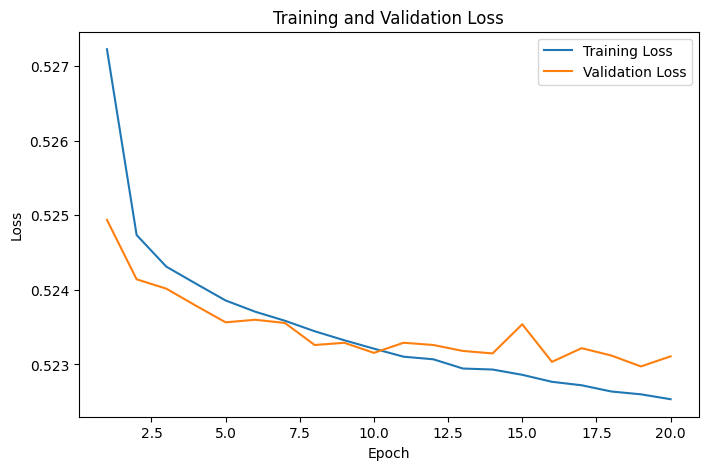

Neural Network Validation Results:
Accuracy: 0.7714482130477536
Precision: 0.7697501289894597
Recall: 0.9973336185622932
F1-score: 0.8688865851406017
AUC-ROC: 0.6217656466366615


In [19]:
# Scale classification data
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_val_c_scaled = scaler_c.transform(X_val_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_c_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_c_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_c_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_clf.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val_clf.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_clf.values, dtype=torch.float32).view(-1, 1)

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# Define neural network
class TipClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super(TipClassifierNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train_c_scaled.shape[1]
model = TipClassifierNN(input_dim)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 20
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")

# 7. Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Validation predictions
model.eval()
with torch.no_grad():
    val_logits = model(X_val_tensor)
    val_probs = torch.sigmoid(val_logits).numpy().flatten()
    val_preds = (val_probs >= 0.5).astype(int)

# Metrics
nn_accuracy = accuracy_score(y_val_clf, val_preds)
nn_precision = precision_score(y_val_clf, val_preds)
nn_recall = recall_score(y_val_clf, val_preds)
nn_f1 = f1_score(y_val_clf, val_preds)
nn_auc = roc_auc_score(y_val_clf, val_probs)

print("Neural Network Validation Results:")
print("Accuracy:", nn_accuracy)
print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1-score:", nn_f1)
print("AUC-ROC:", nn_auc)

The training and validation loss curves show a steady decrease and remain closely aligned, indicating that the model learned meaningful patterns without significant overfitting.

# **Part 3: Model Evaluation & Interpretation**

7. Comprehensive Evaluation

In [20]:
# Linear Regression Test Set

lr_test_pred = lr.predict(X_test)

lr_test_mae = mean_absolute_error(y_test_reg, lr_test_pred)
lr_test_rmse = np.sqrt(mean_squared_error(y_test_reg, lr_test_pred))
lr_test_r2 = r2_score(y_test_reg, lr_test_pred)

print("Linear Regression Test Results:")
print("MAE:", lr_test_mae)
print("RMSE:", lr_test_rmse)
print("R²:", lr_test_r2)

Linear Regression Test Results:
MAE: 1.2122024735979062
RMSE: 2.382156376231309
R²: 0.6229095591625702


In [21]:
# Random Forest Regressor Test Set

rf_reg_test_pred = rf_reg.predict(X_test)

rf_reg_test_mae = mean_absolute_error(y_test_reg, rf_reg_test_pred)
rf_reg_test_rmse = np.sqrt(mean_squared_error(y_test_reg, rf_reg_test_pred))
rf_reg_test_r2 = r2_score(y_test_reg, rf_reg_test_pred)

print("Random Forest Regressor Test Results:")
print("MAE:", rf_reg_test_mae)
print("RMSE:", rf_reg_test_rmse)
print("R²:", rf_reg_test_r2)

Random Forest Regressor Test Results:
MAE: 1.1895616165406078
RMSE: 2.3818384323113118
R²: 0.6230102121785619


In [22]:
# Logistic Regression Test Set

log_test_pred = log_reg.predict(X_test_c)
log_test_prob = log_reg.predict_proba(X_test_c)[:, 1]

log_test_accuracy = accuracy_score(y_test_clf, log_test_pred)
log_test_precision = precision_score(y_test_clf, log_test_pred)
log_test_recall = recall_score(y_test_clf, log_test_pred)
log_test_f1 = f1_score(y_test_clf, log_test_pred)
log_test_auc = roc_auc_score(y_test_clf, log_test_prob)

print("Logistic Regression Test Results:")
print("Accuracy:", log_test_accuracy)
print("Precision:", log_test_precision)
print("Recall:", log_test_recall)
print("F1-score:", log_test_f1)
print("AUC-ROC:", log_test_auc)

Logistic Regression Test Results:
Accuracy: 0.7708484408992023
Precision: 0.7688899219423497
Recall: 0.9982771727296689
F1-score: 0.8686957331099499
AUC-ROC: 0.6101289116748627


In [23]:
# Random Forest Classifier Test Set

rf_test_pred = rf_clf.predict(X_test_c)
rf_test_prob = rf_clf.predict_proba(X_test_c)[:, 1]

rf_test_accuracy = accuracy_score(y_test_clf, rf_test_pred)
rf_test_precision = precision_score(y_test_clf, rf_test_pred)
rf_test_recall = recall_score(y_test_clf, rf_test_pred)
rf_test_f1 = f1_score(y_test_clf, rf_test_pred)
rf_test_auc = roc_auc_score(y_test_clf, rf_test_prob)

print("Random Forest Classifier Test Results:")
print("Accuracy:", rf_test_accuracy)
print("Precision:", rf_test_precision)
print("Recall:", rf_test_recall)
print("F1-score:", rf_test_f1)
print("AUC-ROC:", rf_test_auc)

Random Forest Classifier Test Results:
Accuracy: 0.7711211022480058
Precision: 0.7693721773611475
Recall: 0.9976277699891893
F1-score: 0.8687572976371457
AUC-ROC: 0.6252507426553486


In [24]:
# Neural Network Test Set

model.eval()
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).numpy().flatten()
    test_preds = (test_probs >= 0.5).astype(int)

nn_test_accuracy = accuracy_score(y_test_clf, test_preds)
nn_test_precision = precision_score(y_test_clf, test_preds)
nn_test_recall = recall_score(y_test_clf, test_preds)
nn_test_f1 = f1_score(y_test_clf, test_preds)
nn_test_auc = roc_auc_score(y_test_clf, test_probs)

print("Neural Network Test Results:")
print("Accuracy:", nn_test_accuracy)
print("Precision:", nn_test_precision)
print("Recall:", nn_test_recall)
print("F1-score:", nn_test_f1)
print("AUC-ROC:", nn_test_auc)

Neural Network Test Results:
Accuracy: 0.7708571428571429
Precision: 0.7692278233408748
Recall: 0.9974787893604911
F1-score: 0.8686087802606302
AUC-ROC: 0.6225702669107465


In [26]:
# Regression Summary Table

regression_summary = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [lr_test_mae, rf_reg_test_mae],
    "RMSE": [lr_test_rmse, rf_reg_test_rmse],
    "R²": [lr_test_r2, rf_reg_test_r2]
})

regression_summary


,Model,MAE,RMSE,R²
0,Linear Regression,1.212202,2.382156,0.62291
1,Random Forest Regressor,1.189562,2.381838,0.62301


Although the overall performance of both models was very similar, the Random Forest Regressor slightly outperformed Linear Regression with marginally lower error and a slightly higher R² score.

In [27]:
# Classification Summary Table

classification_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier", "Neural Network"],
    "Accuracy": [log_test_accuracy, rf_test_accuracy, nn_test_accuracy],
    "Precision": [log_test_precision, rf_test_precision, nn_test_precision],
    "Recall": [log_test_recall, rf_test_recall, nn_test_recall],
    "F1-score": [log_test_f1, rf_test_f1, nn_test_f1],
    "AUC-ROC": [log_test_auc, rf_test_auc, nn_test_auc]
})

classification_summary

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Logistic Regression,0.770848,0.768890,0.998277,0.868696,0.610129
1,Random Forest Classifier,0.771121,0.769372,0.997628,0.868757,0.625251
2,Neural Network,0.770857,0.769228,0.997479,0.868609,0.622570


The Random Forest Classifier achieved the best overall performance with the highest AUC-ROC score, while Logistic Regression and the Neural Network produced very similar results.

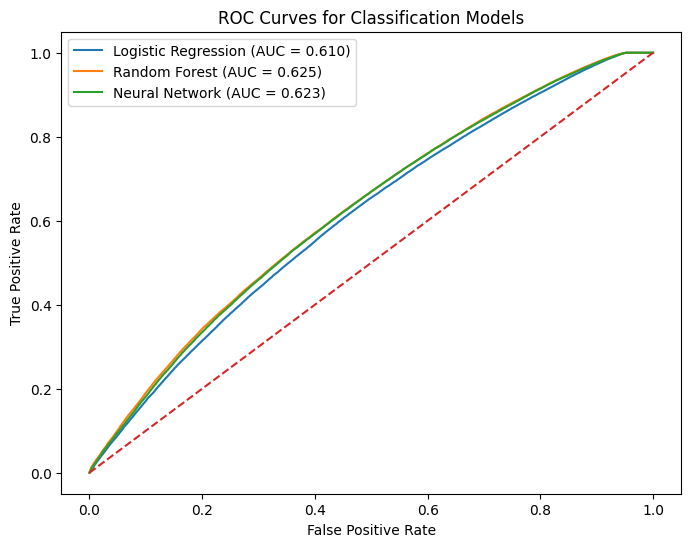

In [28]:
# ROC Curve for Classification Models

log_fpr, log_tpr, _ = roc_curve(y_test_clf, log_test_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test_clf, rf_test_prob)
nn_fpr, nn_tpr, _ = roc_curve(y_test_clf, test_probs)

plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_test_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_test_auc:.3f})")
plt.plot(nn_fpr, nn_tpr, label=f"Neural Network (AUC = {nn_test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend()
plt.show()

The ROC curves show that the RandomForestClassifier achieved the highest AUC-ROC of approximately 0.625, slightly outperforming the neural network and logistic regression models. Although all models perform better than random guessing, the relatively modest AUC values suggest that tipping behavior is difficult to predict using only the available trip and fare features.

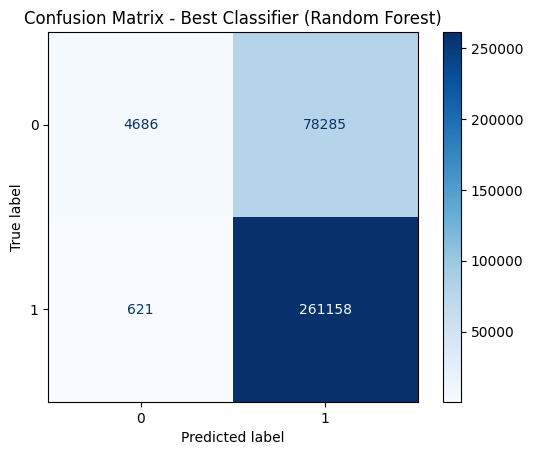

In [29]:
# Confusion Matrix for Best Classification Model

cm = confusion_matrix(y_test_clf, rf_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Best Classifier (Random Forest)")
plt.show()

The confusion matrix reveals that the classifier predicts the positive class (high-tip trips) very frequently. This results in extremely high recall but relatively poor detection of low-tip trips. This behavior likely reflects class imbalance in the dataset, where the majority of trips fall into the high-tip category.

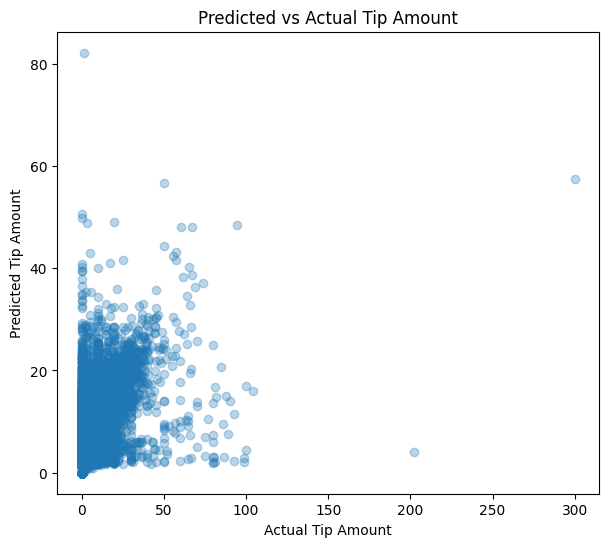

In [30]:
# Scatter Plot for Best Regression Model

best_reg_pred = rf_reg_test_pred   # or rf_reg_test_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_test_reg, best_reg_pred, alpha=0.3)
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Predicted vs Actual Tip Amount")
plt.show()

The predicted vs actual tip plot shows a positive relationship between predicted and actual tip values, indicating that the model captures general trends in tipping behavior. However, there is substantial spread in the predictions, particularly for larger tip amounts suggesting that the model struggles to accurately predict extreme tipping values, which may occur infrequently in the dataset.

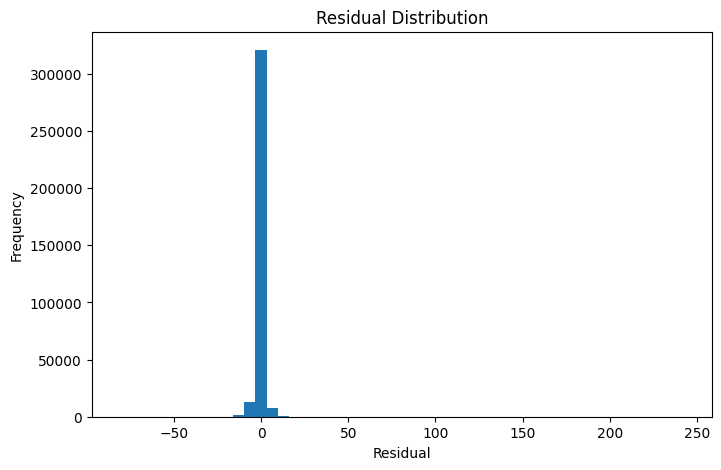

In [31]:
# Residual Analysis for Best Regression Model

residuals = y_test_reg - best_reg_pred

# Residual Distribution

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

The residual distribution is centered around zero, indicating that the model does not exhibit strong systematic bias in over- or under-predicting tip amounts.

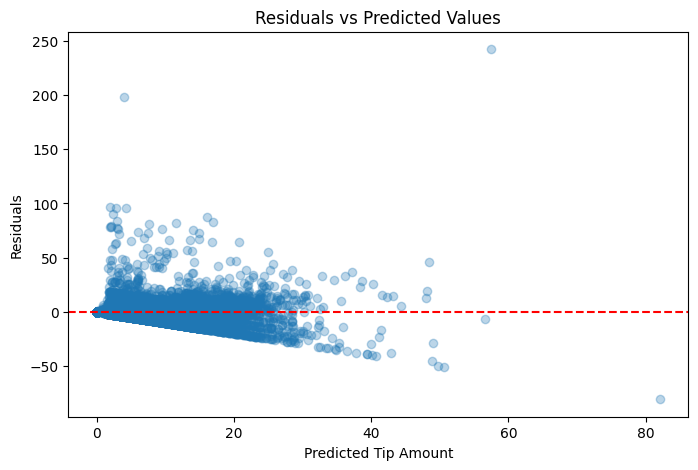

In [32]:
# Residual VS Predicted Values

plt.figure(figsize=(8, 5))
plt.scatter(best_reg_pred, residuals, alpha=0.3)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Tip Amount")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

The residuals vs predicted values plot reveals a triangular pattern, indicating increasing variance in prediction errors as predicted tip values increase. This suggests that larger tip amounts are more difficult to predict accurately, likely due to the greater variability in high-tip scenarios.

8. Feature Importance

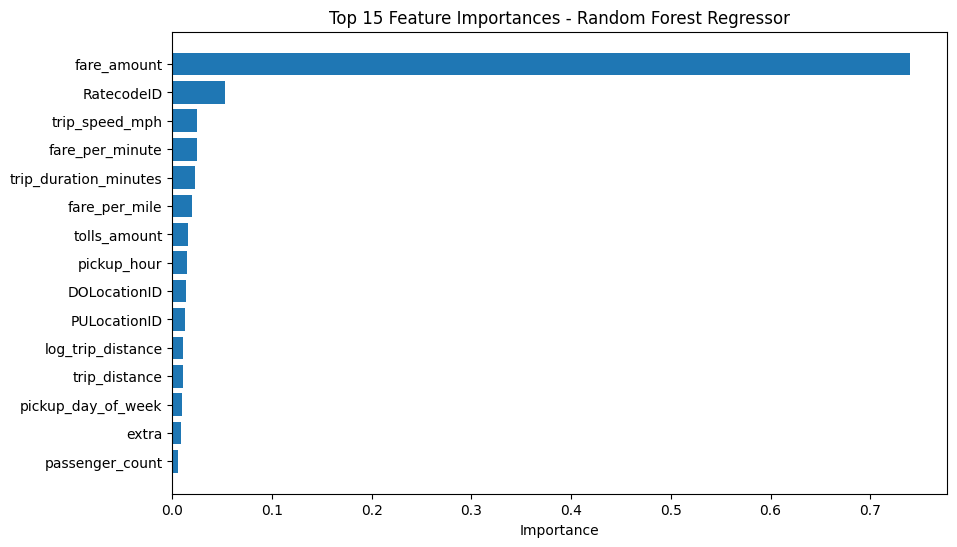

In [37]:
# Feature Importance for Random Forest Model

# Random Forest Regression
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_reg.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest Regressor")
plt.show()

The RandomForestRegressor feature importance results show that fare_amount is by far the most influential feature in predicting tip amount.

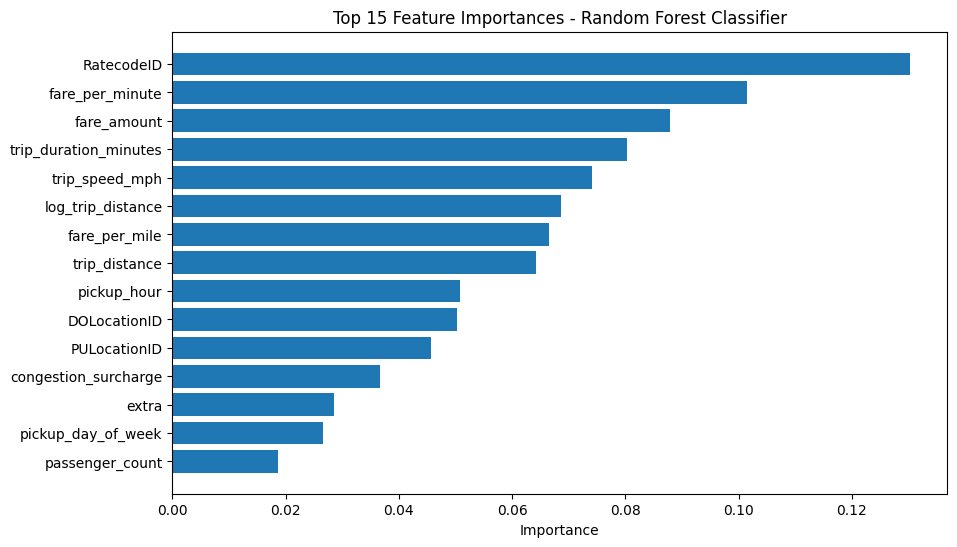

In [38]:
# Random Forest Classification

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest Classifier")
plt.show()

In the classification model, feature importance is more evenly distributed across multiple variables. RatecodeID emerged as the most important predictor.

In [45]:
# Coefficients from Linear/Logistic Regression

# Linear Regression
linear_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=False)

linear_coef_df

,Feature,Coefficient
6,fare_amount,2.383484e+00
9,tolls_amount,4.679944e-01
18,log_trip_distance,4.226657e-01
11,congestion_surcharge,1.980662e-01
12,Airport_fee,1.855335e-01
7,extra,1.563428e-01
8,mta_tax,6.994497e-02
34,dropoff_borough_Queens,6.719632e-02
30,dropoff_borough_Brooklyn,5.328438e-02
14,pickup_hour,3.973534e-02


The linear regression coefficients indicate that fare_amount is the strongest predictor of tip amount, which is expected since taxi tips are typically calculated as a percentage of the fare.

In [44]:
# Logistic Regression

log_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

log_coef_df

,Feature,Coefficient
5,payment_type,3.946365e-01
10,improvement_surcharge,3.940344e-01
30,dropoff_borough_Brooklyn,2.986440e-01
24,pickup_borough_Manhattan,1.918173e-01
12,Airport_fee,1.887993e-01
34,dropoff_borough_Queens,1.874520e-01
8,mta_tax,1.750287e-01
26,pickup_borough_Queens,1.494343e-01
11,congestion_surcharge,1.429069e-01
1,trip_distance,6.261881e-02


Logistic regression coefficients suggest that payment type, surcharges, and location-related features increase the probability of a high-tip trip, indicating that trip context influences tipping behavior.

9. Written Analysis

a) ***Which model performed best for each task and why you think this is the case?***

For the regression task (predicting tip amount), the Random Forest Regressor performed slightly better than Linear Regression, achieving a marginally higher R² score and slightly lower prediction errors. Random Forest models are able to capture nonlinear relationships and interactions between variables, which likely allowed the model to better represent the complex relationships between trip characteristics and tip amount. However, the performance improvement over Linear Regression was relatively small, suggesting that the relationship between many features and tip amount may still be largely linear.

For the classification task (predicting whether a tip is high or low), the Random Forest Classifier achieved the best overall performance, with the highest AUC-ROC score compared to Logistic Regression and the Neural Network model. Although the differences between the models were small, the Random Forest model demonstrated slightly better ability to distinguish between high-tip and low-tip trips. This is likely because ensemble tree methods can capture complex patterns in the data that linear models may not detect.

b) ***What features are most predictive of tip amount and whether this aligns with your intuition?***

Feature importance analysis from the Random Forest Regressor showed that fare_amount was by far the most influential feature in predicting tip amount. This result aligns with intuition, as taxi tips are typically calculated as a percentage of the total fare.

Other important features included variables related to trip characteristics, such as: trip duration, trip distance, fare per minute and trip speed. These features likely reflect the overall cost and duration of a trip, which influence how much a passenger chooses to tip. Additionally, location-related variables such as pickup and drop-off boroughs also contributed to the model, suggesting that geographic factors may influence tipping behavior.

c) ***Limitations of your models (e.g., data leakage concerns, feature limitations, dataset
biases).***

1.   One limitation of the models is the potential dependency between certain features and the target variable. For example, the classification target variable (high_tip) is defined based on whether the tip exceeds a percentage of the fare, while fare_amount is also used as a predictor. This may introduce some degree of correlation between the features and the target.

2.   Another limitation is that the dataset does not include passenger-specific information, such as demographics or customer preferences, which may strongly influence tipping behavior. Additionally, tipping behavior is naturally noisy and influenced by human factors, making it difficult for machine learning models to achieve very high predictive accuracy.


d) ***Potential improvements you would make given more time or data.***

Given more time or additional data, improvements that could have been made include:

1. More advanced feature engineering could be performed, such as creating features related to traffic conditions, weather, or time-of-day demand patterns. These factors may influence passenger satisfaction and tipping behavior.

2. Hyperparameter tuning n this project was limited to a relatively small search space in order to keep training times manageable given the size of the dataset. Given more time, it could be expanded to explore a larger range of model configurations, which may improve predictive performance.

e) ***A brief discussion comparing the neural network approach to the traditional ML
models for this particular problem.***

The neural network model achieved performance similar to the traditional machine learning models but did not significantly outperform them. This is likely because neural networks tend to perform best on very large datasets with complex feature relationships, particularly when working with unstructured data such as images, text, or audio.

In contrast, this dataset consists of structured tabular data, where tree-based methods such as Random Forest often perform very well. As a result, the neural network did not provide a substantial advantage over the traditional models in this case. However, the neural network still demonstrated competitive performance, indicating that it was able to learn meaningful patterns from the data.


# **AI DISCLOSURE**


Chatgpt was used for code debugging.


